# Exchange Monthly Stats

## Executive Summary

This notebook pulls daily exchange metrics from the explorer RPC, aggregates them into monthly summaries, and computes per-exchange distribution statistics from the daily series.

Primary outputs:

1. Monthly new users and monthly volume by exchange.
2. Per-exchange daily distribution stats for volume, cumulative users, and new users.
3. Average volume per cumulative user and average volume per new user.

Important note: the API exposes `cumulative_users`, which is now used as the source-of-truth total user count for each day. The notebook only falls back to a cumulative sum of `daily_new_users` if `cumulative_users` is missing from the response.

## 1. Setup and Data Loading

We use the reusable logic in `script/exchange_stats.py` so the request headers and one-month request splitting remain consistent with `docs/volume_stats.md`.

In [1]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.colors import to_hex
from matplotlib.ticker import FuncFormatter

script_path = str(Path('../../script').resolve())
if script_path not in sys.path:
    sys.path.insert(0, script_path)

import exchange_stats  # noqa: E402

# Force a reload inside Jupyter so notebook imports stay in sync after script edits.
exchange_stats = importlib.reload(exchange_stats)

DEFAULT_METRICS = exchange_stats.DEFAULT_METRICS
build_daily_metric_frame = exchange_stats.build_daily_metric_frame
build_exchange_stat_summary = exchange_stats.build_exchange_stat_summary
build_monthly_report_table = exchange_stats.build_monthly_report_table
build_monthly_report_tables = exchange_stats.build_monthly_report_tables
build_monthly_summary = exchange_stats.build_monthly_summary
fetch_explorer_data_for_range = exchange_stats.fetch_explorer_data_for_range
iter_month_windows = exchange_stats.iter_month_windows

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    go = None
    make_subplots = None
    PLOTLY_AVAILABLE = False


def fmt_billions(x, pos):
    return f'${x / 1e9:.1f}B'


def fmt_millions(x, pos):
    return f'${x / 1e6:.1f}M'


def fmt_thousands(x, pos):
    return f'{x / 1e3:.0f}k'


def safe_divide(numerator, denominator):
    return np.where(denominator != 0, numerator / denominator, np.nan)


def display_metric_table(title, table, formatter):
    display(Markdown(f'### {title}'))
    if table.empty:
        print('No rows available.')
        return

    styled = (
        table.sort_index()
        .style
        .format(formatter, na_rep='-')
        .set_caption(title)
    )
    display(styled)



In [2]:
# Configurable inputs
exchange_slugs = [
    'extended',
    'variational',
    'pacifica'
]

from_date = '2025-06-01'
to_date = '2026-03-14'
metrics = DEFAULT_METRICS
ratio_smoothing_days = 7

palette = dict(zip(exchange_slugs, sns.color_palette('tab10', n_colors=len(exchange_slugs))))

month_windows = list(iter_month_windows(pd.Timestamp(from_date).date(), pd.Timestamp(to_date).date()))
windows_df = pd.DataFrame(month_windows, columns=['request_from', 'request_to'])
# display(windows_df.head(12))
print(f'Total monthly request windows: {len(windows_df)}')

raw_df = fetch_explorer_data_for_range(
    slugs=exchange_slugs,
    metrics=metrics,
    from_date=from_date,
    to_date=to_date,
)

if raw_df.empty:
    daily_df = pd.DataFrame()
    summary_df = pd.DataFrame()
    exchange_stats_df = pd.DataFrame()
    monthly_report_tables = build_monthly_report_tables(summary_df)
    monthly_report_table = build_monthly_report_table(summary_df)
else:
    raw_df = raw_df.copy()
    raw_df['ts'] = pd.to_datetime(raw_df['ts'])
    raw_df['month'] = raw_df['ts'].dt.to_period('M').astype(str)
    raw_df['value'] = pd.to_numeric(raw_df['value'], errors='coerce')
    daily_df = build_daily_metric_frame(raw_df)
    summary_df = build_monthly_summary(raw_df)
    exchange_stats_df = build_exchange_stat_summary(raw_df)
    monthly_report_tables = build_monthly_report_tables(summary_df)
    monthly_report_table = build_monthly_report_table(summary_df)

print(f'Raw rows fetched: {len(raw_df):,}')
print(f'Daily rows: {len(daily_df):,}')
print(f'Monthly summary rows: {len(summary_df):,}')
print(f'Exchange stat rows: {len(exchange_stats_df):,}')

display(summary_df.head(12))



Total monthly request windows: 10
Raw rows fetched: 2,272
Daily rows: 861
Monthly summary rows: 30
Exchange stat rows: 3


,month,project_slug,new_users,cumulative_users,volume,volume_per_user
0,2025-06,extended,1980.0,6322.0,2.360782e+09,373423.331382
1,2025-06,pacifica,226.0,226.0,0.000000e+00,0.000000
2,2025-06,variational,957.0,2350.0,0.000000e+00,0.000000
3,2025-07,extended,2172.0,8494.0,4.659411e+09,548553.246998
4,2025-07,pacifica,418.0,644.0,0.000000e+00,0.000000
5,2025-07,variational,642.0,2992.0,0.000000e+00,0.000000
6,2025-08,extended,2692.0,11186.0,5.198095e+09,464696.472913
7,2025-08,pacifica,1843.0,2487.0,0.000000e+00,0.000000
8,2025-08,variational,800.0,3792.0,0.000000e+00,0.000000
9,2025-09,extended,4237.0,15423.0,6.968861e+09,451848.623420


### Data Coverage and Quality Checks

Before interpreting the output, verify whether each exchange has non-zero daily coverage for the metrics that matter. Sparse or all-zero series will affect distribution statistics and charts.

,project_slug,metric,rows,non_zero_days,first_ts,last_ts
0,extended,cumulative_users,287,287,2025-06-01,2026-03-14
3,pacifica,cumulative_users,287,286,2025-06-01,2026-03-14
6,variational,cumulative_users,287,287,2025-06-01,2026-03-14
1,extended,new_users,287,287,2025-06-01,2026-03-14
4,pacifica,new_users,287,189,2025-06-01,2026-03-14
7,variational,new_users,287,287,2025-06-01,2026-03-14
2,extended,volume,287,287,2025-06-01,2026-03-14
5,pacifica,volume,187,187,2025-09-09,2026-03-14
8,variational,volume,76,76,2025-12-29,2026-03-14


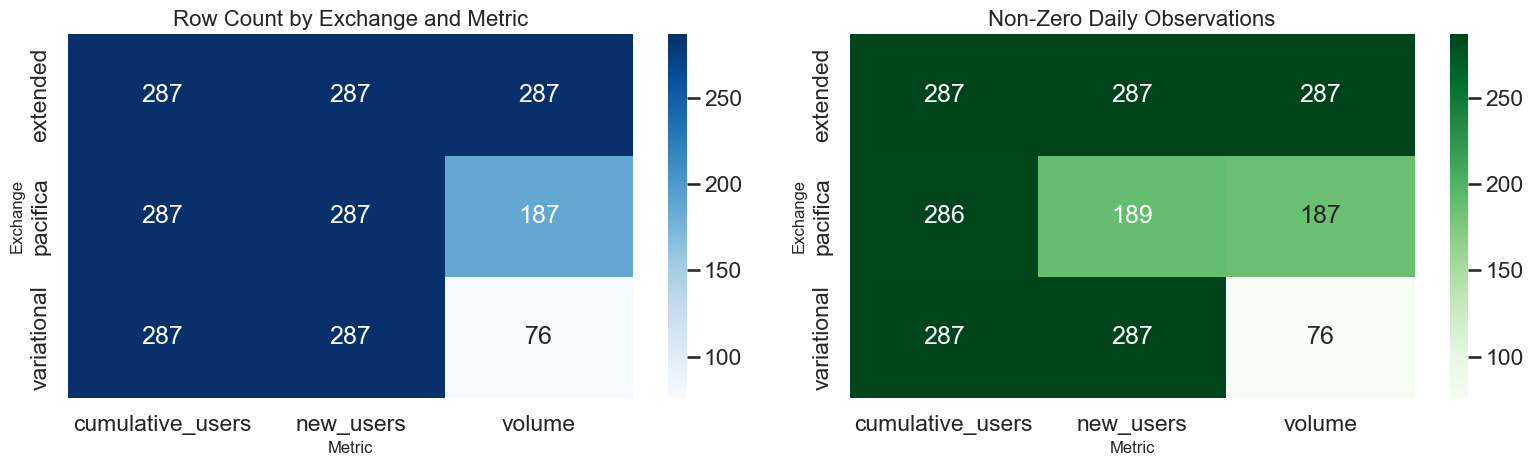

In [3]:
if raw_df.empty:
    print('No raw rows returned for the configured date range.')
else:
    coverage_df = (
        raw_df.groupby(['project_slug', 'metric'])
        .agg(
            rows=('value', 'size'),
            non_zero_days=('value', lambda s: int((s.fillna(0) != 0).sum())),
            first_ts=('ts', 'min'),
            last_ts=('ts', 'max'),
        )
        .reset_index()
        .sort_values(['metric', 'project_slug'])
    )

    display(coverage_df)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    rows_heatmap = coverage_df.pivot(index='project_slug', columns='metric', values='rows').fillna(0)
    sns.heatmap(rows_heatmap, annot=True, fmt='.0f', cmap='Blues', ax=axes[0])
    axes[0].set_title('Row Count by Exchange and Metric')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Exchange')

    non_zero_heatmap = coverage_df.pivot(index='project_slug', columns='metric', values='non_zero_days').fillna(0)
    sns.heatmap(non_zero_heatmap, annot=True, fmt='.0f', cmap='Greens', ax=axes[1])
    axes[1].set_title('Non-Zero Daily Observations')
    axes[1].set_xlabel('Metric')
    axes[1].set_ylabel('Exchange')

    plt.tight_layout()
    plt.show()

## 2. Monthly Growth and Activity

The monthly summary is still useful for top-level comparisons, especially for recent user acquisition and trading activity.

In [4]:
if summary_df.empty:
    print('No monthly summary available.')
else:
    display_metric_table(
        'Monthly New Users by Exchange',
        monthly_report_tables['new_users'],
        '{:,.0f}',
    )
    display_metric_table(
        'Monthly Cumulative Users by Exchange',
        monthly_report_tables['cumulative_users'],
        '{:,.0f}',
    )
    display_metric_table(
        'Monthly Trading Volume by Exchange',
        monthly_report_tables['volume'],
        '${:,.0f}',
    )
    display_metric_table(
        'Monthly Volume per User by Exchange',
        monthly_report_tables['volume_per_user'],
        '${:,.2f}',
    )

    print('Long-form monthly summary:')
    summary_view = summary_df.copy()
    for col in ['new_users', 'cumulative_users', 'volume', 'volume_per_user']:
        if col in summary_view.columns:
            summary_view[col] = summary_view[col].round(2)

    display(summary_view)

    latest_month = summary_view['month'].max()
    latest_rank = (
        summary_view[summary_view['month'] == latest_month]
        .sort_values(['volume', 'new_users'], ascending=False)
        .reset_index(drop=True)
    )

    print(f'Latest month in sample: {latest_month}')
    display(latest_rank)



### Monthly New Users by Exchange

,extended,pacifica,variational
month,,,
2025-06,"1,980",226,957
2025-07,"2,172",418,642
2025-08,"2,692","1,843",800
2025-09,"4,237","12,663","1,163"
2025-10,"7,213","13,030","8,980"
2025-11,"4,123","4,606","15,570"
2025-12,"5,431",396,"15,920"
2026-01,"11,528",0,"25,965"
2026-02,"4,976",0,"8,443"


### Monthly Cumulative Users by Exchange

,extended,pacifica,variational
month,,,
2025-06,"6,322",226,"2,350"
2025-07,"8,494",644,"2,992"
2025-08,"11,186","2,487","3,792"
2025-09,"15,423","15,150","4,955"
2025-10,"22,636","28,180","13,935"
2025-11,"26,759","32,786","29,505"
2025-12,"32,190","33,182","45,425"
2026-01,"43,718","33,182","71,390"
2026-02,"48,694","33,182","79,833"


### Monthly Trading Volume by Exchange

...

,extended,pacifica,variational
month,,,
2025-06,"$373,423.33",$0.00,$0.00
2025-07,"$548,553.25",$0.00,$0.00
2025-08,"$464,696.47",$0.00,$0.00
2025-09,"$451,848.62","$586,813.44",$0.00
2025-10,"$996,540.63","$1,050,173.48",$0.00
2025-11,"$1,021,969.40","$740,380.89",$0.00
2025-12,"$844,625.75","$565,933.78","$82,549.97"
2026-01,"$589,991.96","$735,499.62","$629,465.86"
2026-02,"$325,857.35","$560,194.15","$332,650.19"


Long-form monthly summary:


,month,project_slug,new_users,cumulative_users,volume,volume_per_user
0,2025-06,extended,1980.0,6322.0,2.360782e+09,373423.33
1,2025-06,pacifica,226.0,226.0,0.000000e+00,0.00
2,2025-06,variational,957.0,2350.0,0.000000e+00,0.00
3,2025-07,extended,2172.0,8494.0,4.659411e+09,548553.25
4,2025-07,pacifica,418.0,644.0,0.000000e+00,0.00
5,2025-07,variational,642.0,2992.0,0.000000e+00,0.00
6,2025-08,extended,2692.0,11186.0,5.198095e+09,464696.47
7,2025-08,pacifica,1843.0,2487.0,0.000000e+00,0.00
8,2025-08,variational,800.0,3792.0,0.000000e+00,0.00
9,2025-09,extended,4237.0,15423.0,6.968861e+09,451848.62


Latest month in sample: 2026-03


,month,project_slug,new_users,cumulative_users,volume,volume_per_user
0,2026-03,variational,4597.0,84430.0,1.278429e+10,151418.82
1,2026-03,extended,1162.0,49856.0,5.833120e+09,116999.35
2,2026-03,pacifica,0.0,33182.0,5.383373e+09,162237.74


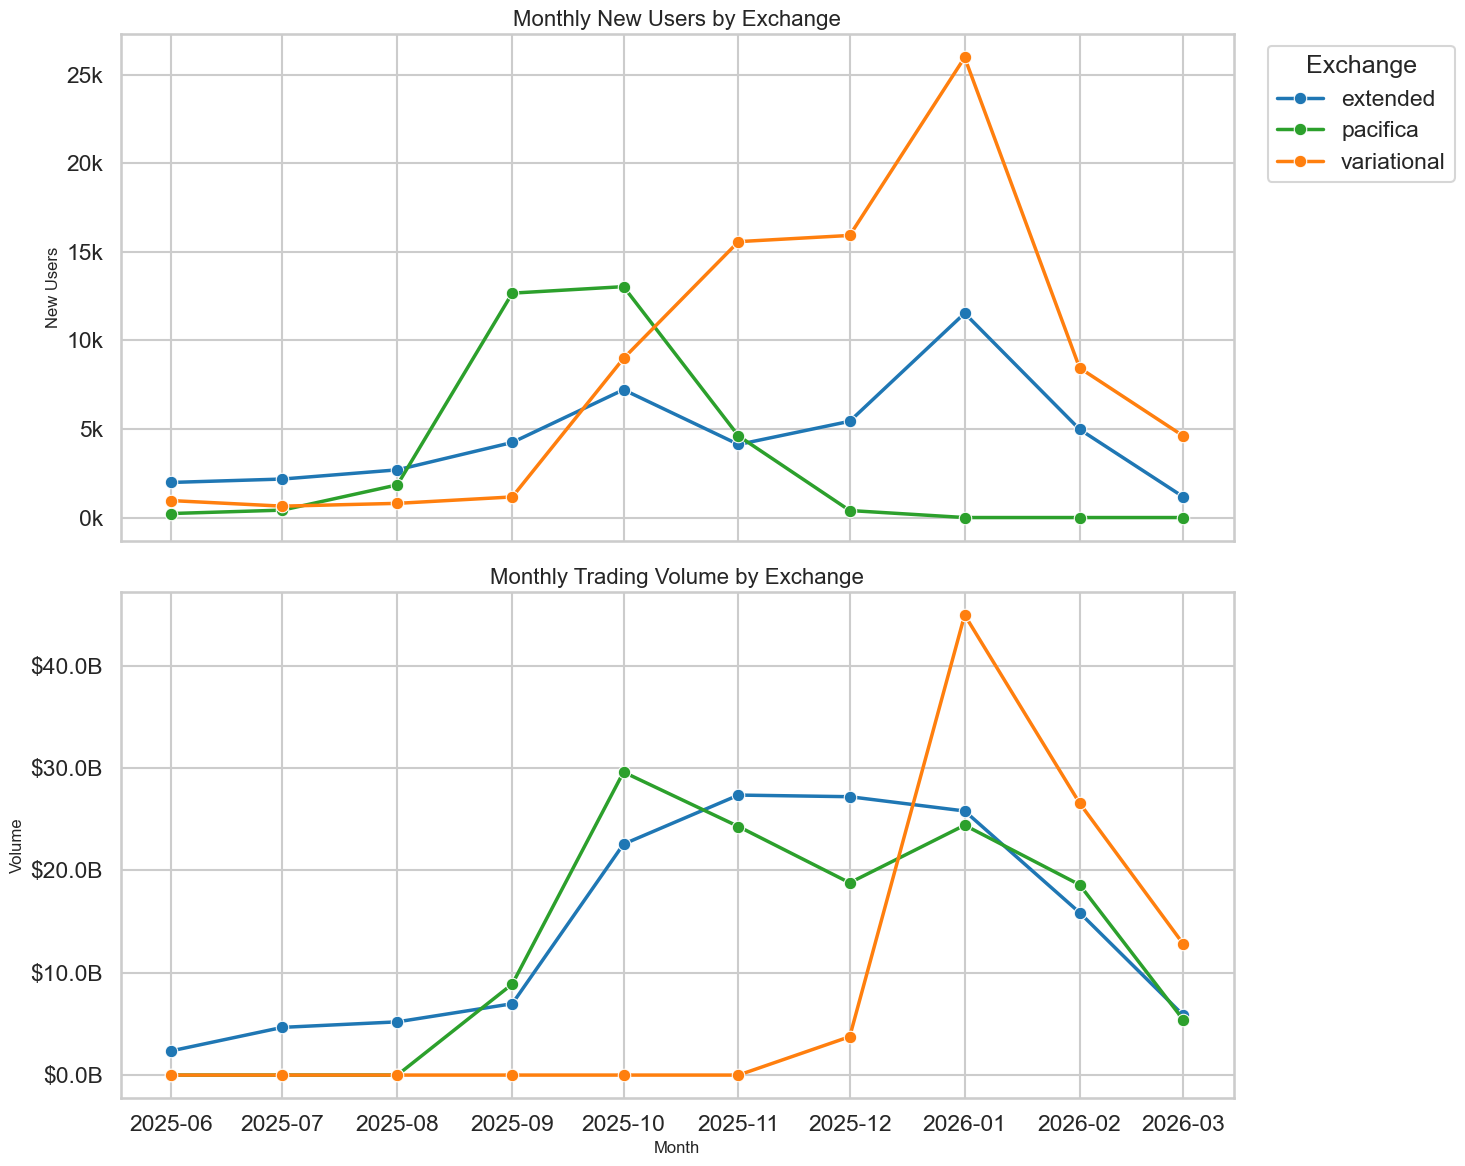

In [5]:
if summary_df.empty:
    print('No data available for monthly charts.')
else:
    plot_df = summary_df.copy()
    plot_df['month_dt'] = pd.to_datetime(plot_df['month'] + '-01')

    fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

    sns.lineplot(
        data=plot_df,
        x='month_dt',
        y='new_users',
        hue='project_slug',
        palette=palette,
        marker='o',
        linewidth=2.5,
        ax=axes[0],
    )
    axes[0].set_title('Monthly New Users by Exchange')
    axes[0].set_ylabel('New Users')
    axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
    axes[0].legend(title='Exchange', bbox_to_anchor=(1.02, 1), loc='upper left')

    sns.lineplot(
        data=plot_df,
        x='month_dt',
        y='volume',
        hue='project_slug',
        palette=palette,
        marker='o',
        linewidth=2.5,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title('Monthly Trading Volume by Exchange')
    axes[1].set_ylabel('Volume')
    axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_billions))

    axes[1].set_xlabel('Month')

    plt.tight_layout()
    plt.show()

## 3. Daily Exchange-Level Distribution Statistics

For each exchange, compute the requested descriptive statistics on daily series:

- Daily trading volume
- Cumulative users
- Daily new users
We also compute:

- `avg_volume_per_user` = average of `daily_volume / cumulative_users`
- `avg_volume_per_new_user` = average of `daily_volume / daily_new_users`, excluding zero-new-user days

In [6]:
if exchange_stats_df.empty:
    print('No exchange-level distribution stats available.')
else:
    stats_view = exchange_stats_df.copy()
    numeric_cols = stats_view.select_dtypes(include=[np.number]).columns
    stats_view[numeric_cols] = stats_view[numeric_cols].round(2)
    display(stats_view)


,project_slug,daily_volume_min,daily_volume_p5,daily_volume_mean,daily_volume_median,daily_volume_p95,daily_volume_p99,daily_volume_max,cumulative_users_min,cumulative_users_p5,cumulative_users_mean,cumulative_users_median,cumulative_users_p95,cumulative_users_p99,cumulative_users_max,daily_new_users_min,daily_new_users_p5,daily_new_users_mean,daily_new_users_median,daily_new_users_p95,daily_new_users_p99,daily_new_users_max,avg_volume_per_user,avg_volume_per_new_user
0,extended,33008899.0,6.655644e+07,5.009544e+08,4.156951e+08,1.099772e+09,1.456532e+09,1.687914e+09,4394.0,5237.0,22777.38,20974.0,48662.8,49677.28,49856.0,18.0,34.3,158.59,124.0,420.2,590.44,760.0,22409.32,3625140.17
1,pacifica,127290401.0,2.332117e+08,6.947280e+08,6.772405e+08,1.202392e+09,1.618919e+09,1.732409e+09,0.0,90.8,18647.09,24647.0,33182.0,33182.00,33182.0,0.0,0.0,115.62,14.0,606.8,1063.12,1433.0,28007.88,6960737.38
2,variational,360211654.0,6.220958e+08,1.158265e+09,1.123298e+09,1.878660e+09,1.992705e+09,1.995042e+09,1414.0,2015.1,26348.93,9739.0,79730.1,83623.08,84430.0,2.0,8.3,289.33,217.0,950.9,1327.42,1813.0,17872.71,2635984.24


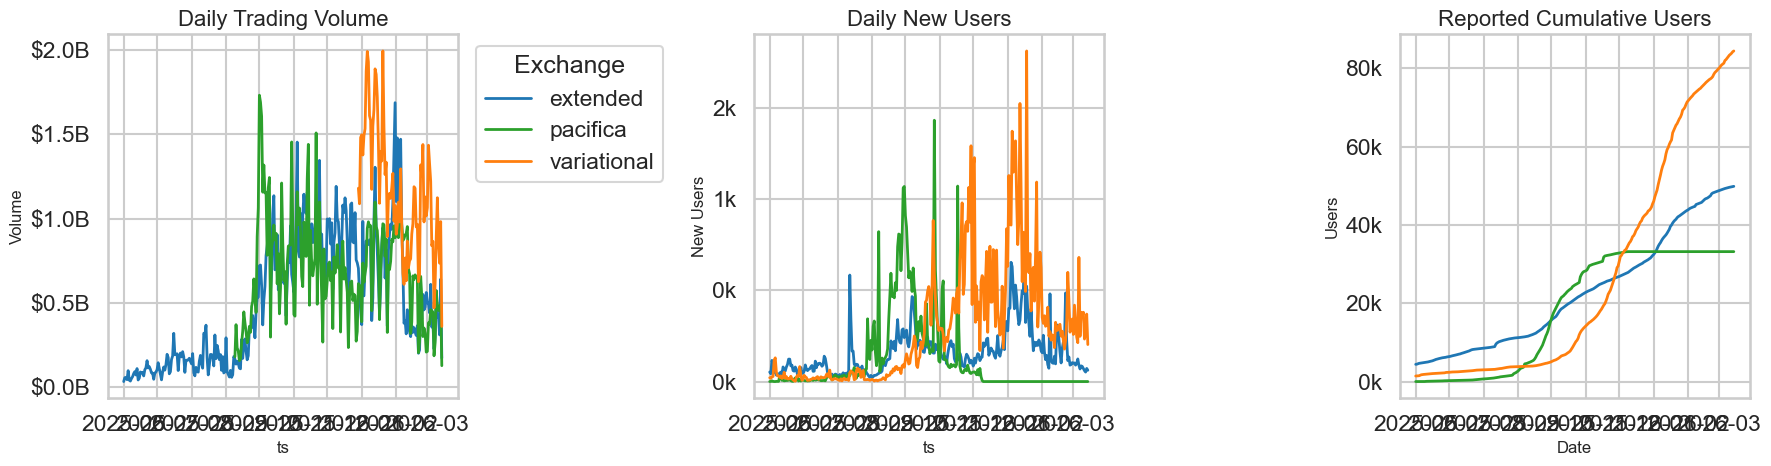

In [7]:
if daily_df.empty:
    print('No daily data available for charting.')
else:
    plot_daily = daily_df.copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    sns.lineplot(
        data=plot_daily,
        x='ts',
        y='daily_volume',
        hue='project_slug',
        palette=palette,
        linewidth=2,
        ax=axes[0],
    )
    axes[0].set_title('Daily Trading Volume')
    axes[0].set_ylabel('Volume')
    axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_billions))
    axes[0].legend(title='Exchange', bbox_to_anchor=(1.02, 1), loc='upper left')

    sns.lineplot(
        data=plot_daily,
        x='ts',
        y='daily_new_users',
        hue='project_slug',
        palette=palette,
        linewidth=2,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title('Daily New Users')
    axes[1].set_ylabel('New Users')
    axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_thousands))

    sns.lineplot(
        data=plot_daily,
        x='ts',
        y='cumulative_users',
        hue='project_slug',
        palette=palette,
        linewidth=2,
        legend=False,
        ax=axes[2],
    )
    axes[2].set_title('Reported Cumulative Users')
    axes[2].set_ylabel('Users')
    axes[2].yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    plt.show()

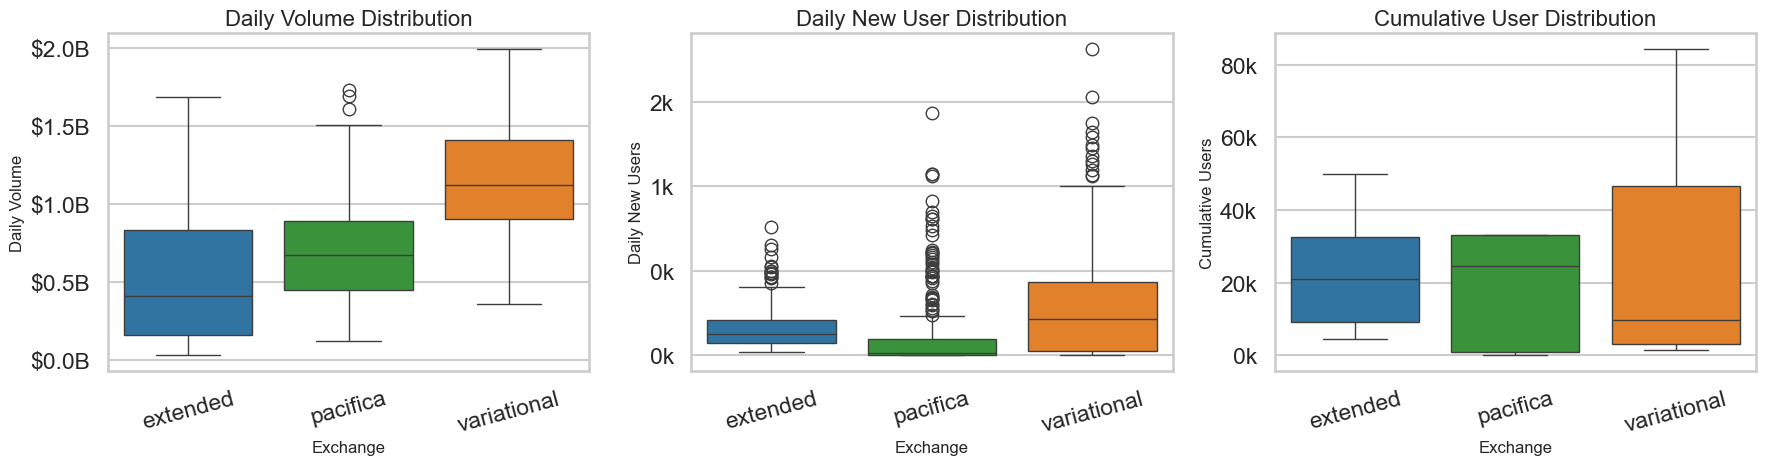

In [8]:
if daily_df.empty:
    print('No daily data available for distribution plots.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.boxplot(
        data=daily_df,
        x='project_slug',
        y='daily_volume',
        hue='project_slug',
        palette=palette,
        dodge=False,
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title('Daily Volume Distribution')
    axes[0].set_xlabel('Exchange')
    axes[0].set_ylabel('Daily Volume')
    axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_billions))
    axes[0].tick_params(axis='x', rotation=15)

    sns.boxplot(
        data=daily_df,
        x='project_slug',
        y='daily_new_users',
        hue='project_slug',
        palette=palette,
        dodge=False,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title('Daily New User Distribution')
    axes[1].set_xlabel('Exchange')
    axes[1].set_ylabel('Daily New Users')
    axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
    axes[1].tick_params(axis='x', rotation=15)

    sns.boxplot(
        data=daily_df,
        x='project_slug',
        y='cumulative_users',
        hue='project_slug',
        palette=palette,
        dodge=False,
        legend=False,
        ax=axes[2],
    )
    axes[2].set_title('Cumulative User Distribution')
    axes[2].set_xlabel('Exchange')
    axes[2].set_ylabel('Cumulative Users')
    axes[2].yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
    axes[2].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

,project_slug,avg_volume_per_user,median_volume_per_user,avg_volume_per_new_user,median_volume_per_new_user
0,extended,22409.32,21185.55,3625140.17,3048596.99
1,pacifica,28007.88,24455.54,6960737.38,2762532.46
2,variational,17872.71,15479.50,2635984.24,2564932.74


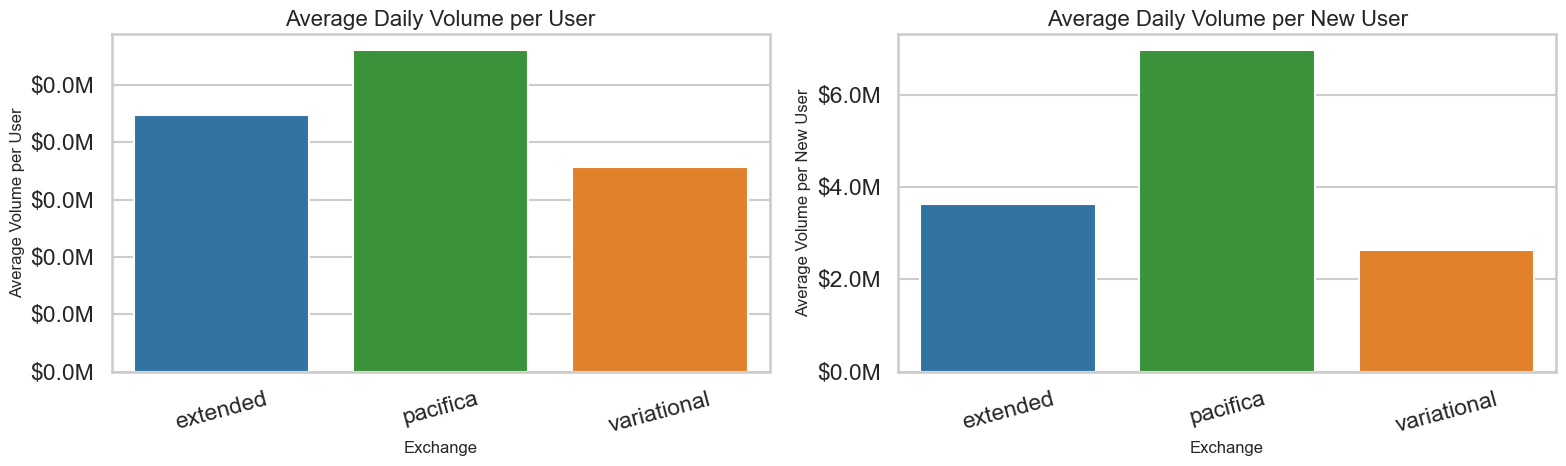

In [9]:
if daily_df.empty:
    print('No daily ratio data available.')
else:
    ratio_summary = (
        daily_df.groupby('project_slug')
        .agg(
            avg_volume_per_user=('volume_per_user', 'mean'),
            median_volume_per_user=('volume_per_user', 'median'),
            avg_volume_per_new_user=('volume_per_new_user', 'mean'),
            median_volume_per_new_user=('volume_per_new_user', 'median'),
        )
        .reset_index()
    )

    display(ratio_summary.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(
        data=ratio_summary,
        x='project_slug',
        y='avg_volume_per_user',
        hue='project_slug',
        palette=palette,
        dodge=False,
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title('Average Daily Volume per User')
    axes[0].set_xlabel('Exchange')
    axes[0].set_ylabel('Average Volume per User')
    axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_millions))
    axes[0].tick_params(axis='x', rotation=15)

    sns.barplot(
        data=ratio_summary,
        x='project_slug',
        y='avg_volume_per_new_user',
        hue='project_slug',
        palette=palette,
        dodge=False,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title('Average Daily Volume per New User')
    axes[1].set_xlabel('Exchange')
    axes[1].set_ylabel('Average Volume per New User')
    axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_millions))
    axes[1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

## 4. Interactive Ratio Time Series

The sample-average bars above are useful, but they hide when ratio shifts happen. This interactive section plots rolling averages of `daily_volume / cumulative_users` and `daily_volume / daily_new_users` so you can inspect persistence, spikes, and regime changes with unified hover.

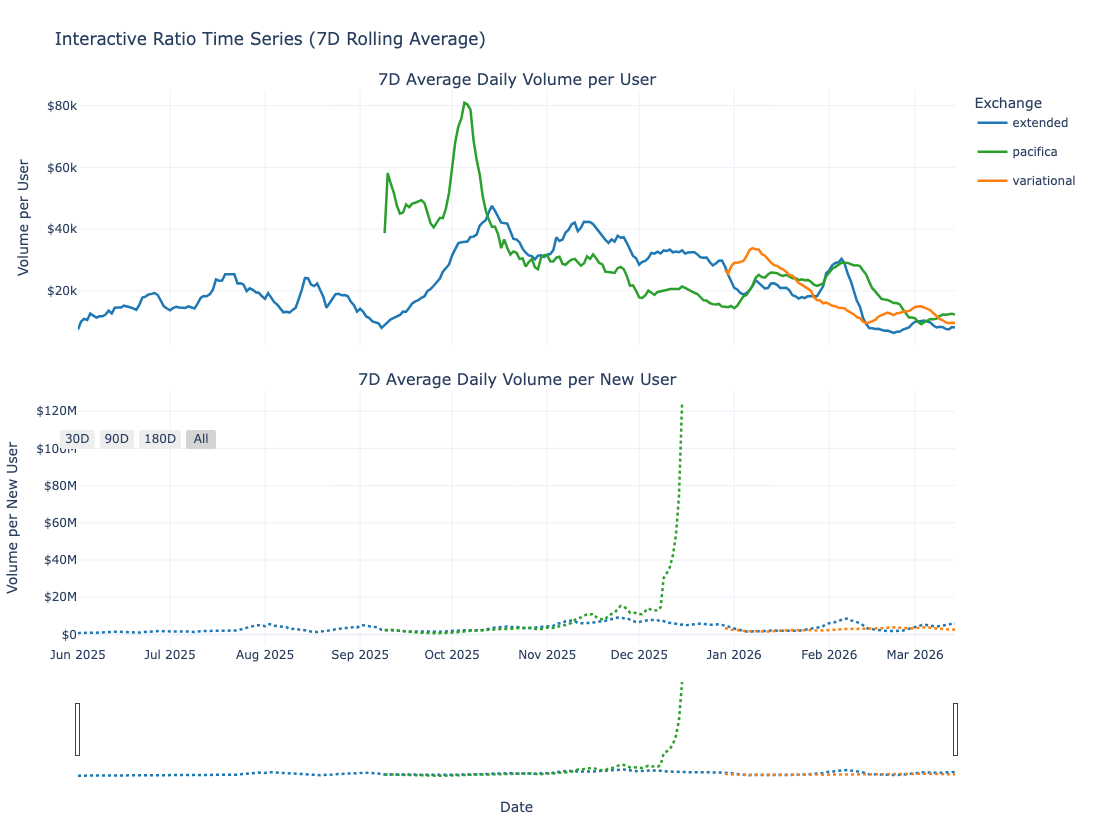

In [10]:
if daily_df.empty:
    print('No daily ratio data available for interactive charting.')
elif not PLOTLY_AVAILABLE:
    print('Plotly is not installed in this environment. Static ratio charts above remain available.')
else:
    ratio_ts = daily_df.copy().sort_values(['project_slug', 'ts'])
    for column in [
        'daily_volume',
        'daily_new_users',
        'cumulative_users',
        'volume_per_user',
        'volume_per_new_user',
    ]:
        ratio_ts[column] = pd.to_numeric(ratio_ts[column], errors='coerce')
    ratio_ts['volume_per_user_avg'] = (
        ratio_ts.groupby('project_slug')['volume_per_user']
        .transform(lambda s: s.rolling(ratio_smoothing_days, min_periods=1).mean())
    )
    ratio_ts['volume_per_new_user_avg'] = (
        ratio_ts.groupby('project_slug')['volume_per_new_user']
        .transform(lambda s: s.rolling(ratio_smoothing_days, min_periods=1).mean())
    )

    fig = make_subplots(
        rows=2,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=(
            f'{ratio_smoothing_days}D Average Daily Volume per User',
            f'{ratio_smoothing_days}D Average Daily Volume per New User',
        ),
    )

    for project_slug, project_df in ratio_ts.groupby('project_slug'):
        project_df = project_df.sort_values('ts')
        color = to_hex(palette.get(project_slug, '#1f77b4'))

        fig.add_trace(
            go.Scatter(
                x=project_df['ts'],
                y=project_df['volume_per_user_avg'],
                mode='lines',
                name=project_slug,
                legendgroup=project_slug,
                line=dict(color=color, width=2.5),
                customdata=np.column_stack([
                    project_df['daily_volume'].to_numpy(),
                    project_df['cumulative_users'].to_numpy(),
                    project_df['volume_per_user'].to_numpy(),
                ]),
                hovertemplate=(
                    '%{x|%b %d, %Y}<br>'
                    f'{project_slug}<br>'
                    f'{ratio_smoothing_days}D avg vol / user: $%{{y:,.0f}}<br>'
                    'Daily vol / user: $%{customdata[2]:,.0f}<br>'
                    'Daily volume: $%{customdata[0]:,.0f}<br>'
                    'Cumulative users: %{customdata[1]:,.0f}'
                    '<extra></extra>'
                ),
            ),
            row=1,
            col=1,
        )

        fig.add_trace(
            go.Scatter(
                x=project_df['ts'],
                y=project_df['volume_per_new_user_avg'],
                mode='lines',
                name=project_slug,
                legendgroup=project_slug,
                showlegend=False,
                line=dict(color=color, width=2.5, dash='dot'),
                customdata=np.column_stack([
                    project_df['daily_volume'].to_numpy(),
                    project_df['daily_new_users'].to_numpy(),
                    project_df['volume_per_new_user'].to_numpy(),
                ]),
                hovertemplate=(
                    '%{x|%b %d, %Y}<br>'
                    f'{project_slug}<br>'
                    f'{ratio_smoothing_days}D avg vol / new user: $%{{y:,.0f}}<br>'
                    'Daily vol / new user: $%{customdata[2]:,.0f}<br>'
                    'Daily volume: $%{customdata[0]:,.0f}<br>'
                    'Daily new users: %{customdata[1]:,.0f}'
                    '<extra></extra>'
                ),
            ),
            row=2,
            col=1,
        )

    fig.update_layout(
        height=820,
        template='plotly_white',
        title=f'Interactive Ratio Time Series ({ratio_smoothing_days}D Rolling Average)',
        hovermode='x unified',
        legend_title_text='Exchange',
        margin=dict(l=60, r=40, t=90, b=40),
    )
    fig.update_yaxes(title_text='Volume per User', tickprefix='$', separatethousands=True, row=1, col=1)
    fig.update_yaxes(title_text='Volume per New User', tickprefix='$', separatethousands=True, row=2, col=1)
    fig.update_xaxes(
        title_text='Date',
        row=2,
        col=1,
        rangeslider=dict(visible=True),
        rangeselector=dict(
            buttons=[
                dict(count=30, label='30D', step='day', stepmode='backward'),
                dict(count=90, label='90D', step='day', stepmode='backward'),
                dict(count=180, label='180D', step='day', stepmode='backward'),
                dict(step='all', label='All'),
            ]
        ),
    )
    fig.show()

## 5. Export

Save the raw daily rows, the engineered daily frame, the monthly summary, and the per-exchange descriptive statistics so later notebooks can reuse the same pull.

In [11]:
output_dir = Path('../../data/exchange_stats').resolve()
output_dir.mkdir(parents=True, exist_ok=True)

raw_path = output_dir / 'raw_rows.csv'
daily_path = output_dir / 'daily_metrics.csv'
summary_path = output_dir / 'monthly_summary.csv'
stats_path = output_dir / 'exchange_distribution_stats.csv'
report_new_users_path = output_dir / 'monthly_new_users_by_exchange.csv'
report_cumulative_users_path = output_dir / 'monthly_cumulative_users_by_exchange.csv'
report_volume_path = output_dir / 'monthly_volume_by_exchange.csv'
report_volume_per_user_path = output_dir / 'monthly_volume_per_user_by_exchange.csv'
report_combined_path = output_dir / 'monthly_report_table.csv'

raw_df.to_csv(raw_path, index=False)
daily_df.to_csv(daily_path, index=False)
summary_df.to_csv(summary_path, index=False)
exchange_stats_df.to_csv(stats_path, index=False)
monthly_report_tables['new_users'].to_csv(report_new_users_path)
monthly_report_tables['cumulative_users'].to_csv(report_cumulative_users_path)
monthly_report_tables['volume'].to_csv(report_volume_path)
monthly_report_tables['volume_per_user'].to_csv(report_volume_per_user_path)
monthly_report_table.to_csv(report_combined_path)

print(f'Saved raw rows to: {raw_path}')
print(f'Saved daily metrics to: {daily_path}')
print(f'Saved monthly summary to: {summary_path}')
print(f'Saved exchange distribution stats to: {stats_path}')
print(f'Saved monthly new users table to: {report_new_users_path}')
print(f'Saved monthly cumulative users table to: {report_cumulative_users_path}')
print(f'Saved monthly volume table to: {report_volume_path}')
print(f'Saved monthly volume per user table to: {report_volume_per_user_path}')
print(f'Saved combined monthly report table to: {report_combined_path}')



Saved raw rows to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/raw_rows.csv
Saved daily metrics to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/daily_metrics.csv
Saved monthly summary to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/monthly_summary.csv
Saved exchange distribution stats to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/exchange_distribution_stats.csv
Saved monthly new users table to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/monthly_new_users_by_exchange.csv
Saved monthly cumulative users table to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/monthly_cumulative_users_by_exchange.csv
Saved monthly volume table to: /Users/lamp/go/src/github.com/LampardNguyen234/clob-risk-modelling/data/exchange_stats/monthly_volume_by_ex